## LINK DATASET
https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset/code/data?datasetId=1209633&sortBy=voteCount

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Path to dataset files: /kaggle/input/breast-ultrasound-images-dataset


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
from glob import glob
from shutil import copyfile
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import MeanIoU, Precision, Recall
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
destination_path = "/content/drive/MyDrive/Breast_Dataset"

In [ ]:
import shutil

source_path = path

shutil.copytree(source_path, destination_path)

'/content/drive/MyDrive/Breast_Dataset'

In [4]:
for dirName,_,fileName in os.walk(destination_path):
   print(dirName)

/content/drive/MyDrive/Breast_Dataset
/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT
/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT/malignant
/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT/normal
/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT/benign


In [5]:
base_dir = "/content/Breast_Dataset"

os.makedirs(os.path.join(base_dir, "benign"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "normal"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "malignant"), exist_ok=True)

In [6]:
def move_all_images(SOURCE, DESTINATION):
    files = []

    for filename in os.listdir(SOURCE):
        file_path = os.path.join(SOURCE, filename)

        if os.path.getsize(file_path) > 0:
            files.append(filename)
        else:
            print(filename + " is corrupted, skipping.")

    print(f"Total valid images: {len(files)}")

    for filename in files:
        source_path = os.path.join(SOURCE, filename)
        dest_path = os.path.join(DESTINATION, filename)

        copyfile(source_path, dest_path)

    print("Done copying all images")

In [7]:
normal_SOURCE_DIR = "/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT/normal/"
benign_SOURCE_DIR = "/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT/benign/"
malignant_SOURCE_DIR = "/content/drive/MyDrive/Breast_Dataset/Dataset_BUSI_with_GT/malignant/"

benign="/content/Breast_Dataset/benign/"
normal="/content/Breast_Dataset/normal/"
malignant="/content/Breast_Dataset/malignant/"

In [8]:
move_all_images(normal_SOURCE_DIR, normal)
move_all_images(benign_SOURCE_DIR, benign)
move_all_images(malignant_SOURCE_DIR, malignant)

Total valid images: 266
Done copying all images
Total valid images: 891
Done copying all images
Total valid images: 421
Done copying all images


In [9]:
paths = glob('/content/Breast_Dataset/*/*')

print(f"'normal' class has {len([i for i in paths if 'normal' in i and 'mask' not in i])} images and {len([i for i in paths if 'normal' in i and 'mask' in i])} masks.")
print(f"'benign' class has {len([i for i in paths if 'benign' in i and 'mask' not in i])} images and {len([i for i in paths if 'benign' in i and 'mask' in i])} masks.")
print(f"'malignant' class has {len([i for i in paths if 'malignant' in i and 'mask' not in i])} images and {len([i for i in paths if 'malignant' in i and 'mask' in i])} masks.")
print(f"\nThere are total of {len([i for i in paths if 'mask' not in i])} images and {len([i for i in paths if 'mask' in i])} masks.")

'normal' class has 133 images and 133 masks.
'benign' class has 437 images and 454 masks.
'malignant' class has 210 images and 211 masks.

There are total of 780 images and 798 masks.


In [10]:
sorted(glob('/content/Breast_Dataset/benign/*'))[4:7]

['/content/Breast_Dataset/benign/benign (100).png',
 '/content/Breast_Dataset/benign/benign (100)_mask.png',
 '/content/Breast_Dataset/benign/benign (100)_mask_1.png']

In [11]:
def load_image(path, size):
    image = cv2.imread(path)
    image = cv2.resize(image, (size,size))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)   # shape: (size,size,3) -> (size,size,1)
    image = image/255.   # normalize
    return image

def load_data(root_path, size):
    images = []
    masks = []

    x = 0   # additional variable to identify images consisting of 2 or more masks

    for path in sorted(glob(root_path)):
        img = load_image(path, size)   # read mask or image

        if '_mask' in path:
            if x:   # this image has masks more than one
                masks[-1] += img   # add the mask to the last mask

                # When 2 masks are added, the range can increase by 0-2. So we will reduce it again to the range 0-1.
                masks[-1] = np.array(masks[-1]>0.5, dtype='float64')
            else:
                masks.append(img)
                x = 1   # if the image has a mask again, the above code will run next time
        else:
            images.append(img)
            x = 0   # for moving to the next image
    return np.array(images), np.array(masks)

In [12]:
size =128
X,y =load_data(root_path='/content/Breast_Dataset/*/*', size=size)


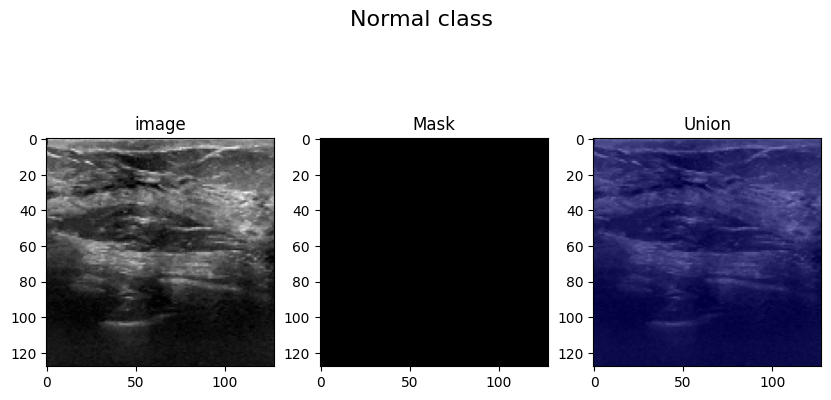

In [13]:
fig , ax = plt.subplots(1,3,figsize=(10,5))
i = np.random.randint(647,780)
ax[0].imshow (X[i] ,cmap='gray')
ax[0].set_title('image')

ax[1].imshow (y[i],cmap='gray')
ax[1].set_title('Mask')

ax[2].imshow(X[i], cmap='gray')
ax[2].imshow(tf.squeeze(y[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')

fig.suptitle('Normal class', fontsize=16)
plt.show()

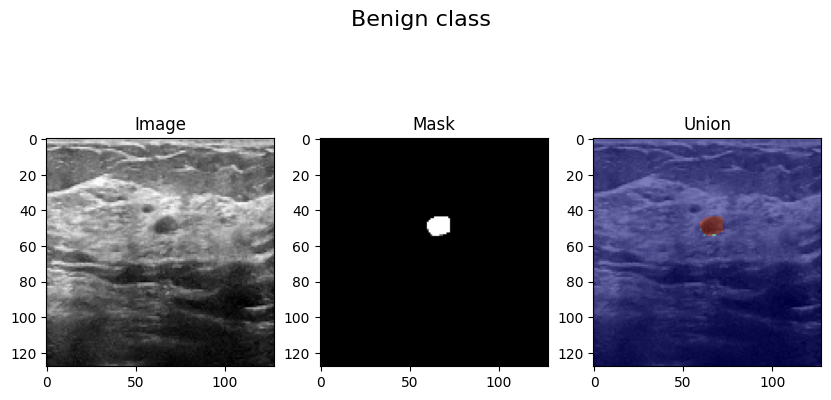

In [14]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

i = np.random.randint(437)
ax[0].imshow(X[i], cmap='gray')
ax[0].set_title('Image')
ax[1].imshow(y[i], cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(X[i], cmap='gray')
ax[2].imshow(tf.squeeze(y[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')
fig.suptitle('Benign class', fontsize=16)
plt.show()

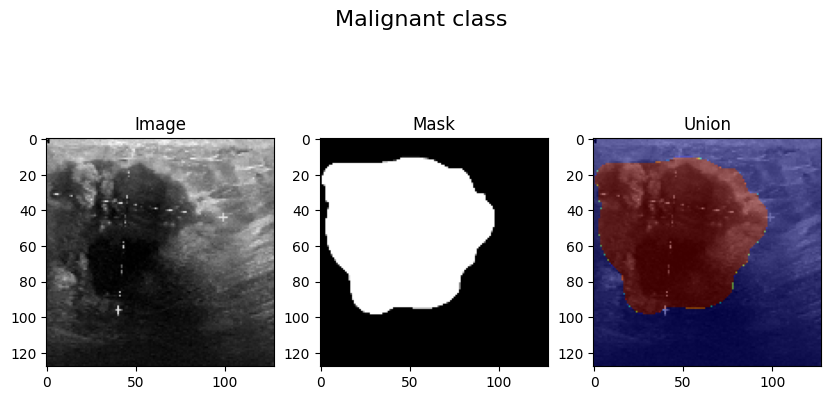

In [15]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

i = np.random.randint(437,647)
ax[0].imshow(X[i], cmap='gray')
ax[0].set_title('Image')
ax[1].imshow(y[i], cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(X[i], cmap='gray')
ax[2].imshow(tf.squeeze(y[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')
fig.suptitle('Malignant class', fontsize=16)
plt.show()

In [16]:
# drop normal class because normal class has not mask
X = X[:647]
y = y[:647]

print(f"X shape: {X.shape}     |  y shape: {y.shape}")

# prepare data to modeling
X = np.expand_dims(X, -1)
y = np.expand_dims(y, -1)

print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")

X shape: (647, 128, 128)     |  y shape: (647, 128, 128)

X shape: (647, 128, 128, 1)  |  y shape: (647, 128, 128, 1)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

print('X_train shape:',X_train.shape)
print('y_train shape:',y_train.shape)
print('X_test shape:',X_test.shape)
print('y_test shape:',y_test.shape)

X_train shape: (582, 128, 128, 1)
y_train shape: (582, 128, 128, 1)
X_test shape: (65, 128, 128, 1)
y_test shape: (65, 128, 128, 1)


In [18]:
def conv_block(input, num_filters):
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(input)
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(conv)
    return conv

In [19]:
def encoder_block(input, num_filters):
    conv = conv_block(input, num_filters)
    pool = MaxPooling2D((2, 2))(conv)
    return conv, pool

In [20]:
def decoder_block(input, skip_features, num_filters):
    uconv = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    con = concatenate([uconv, skip_features])
    conv = conv_block(con, num_filters)
    return conv

In [34]:
def build_model(input_shape):
    input_layer = Input(input_shape)

    s1, p1 = encoder_block(input_layer, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    output_layer = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(input_layer, output_layer, name="U-Net")
    return model

model = build_model(input_shape=(size, size, 1))
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])

In [35]:
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_25[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 512) │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_7[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 8, 8,      │  9,438,208 │ conv2d_27[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 16, 16,    │  2,097,664 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(X_train,
                    y_train,
                    epochs = 100,
                    validation_data = (X_test,y_test))

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 889ms/step - accuracy: 0.8739 - loss: 0.4420 - val_accuracy: 0.9243 - val_loss: 0.3325
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 439ms/step - accuracy: 0.9021 - loss: 0.3405 - val_accuracy: 0.9243 - val_loss: 0.3352
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 430ms/step - accuracy: 0.9029 - loss: 0.3153 - val_accuracy: 0.9253 - val_loss: 0.2655
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 426ms/step - accuracy: 0.9042 - loss: 0.2563 - val_accuracy: 0.7683 - val_loss: 0.4471
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 416ms/step - accuracy: 0.8969 - loss: 0.2784 - val_accuracy: 0.9243 - val_loss: 0.2139
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 411ms/step - accuracy: 0.9024 - loss: 0.2285 - val_accuracy: 0.9248 - val_loss: 0.1985
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 413ms/step - accuracy: 0.9047 - loss: 0.2133 - val_accuracy: 0.9267 - val_loss: 0.2085
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 409ms/step - accuracy: 0.9086 - loss: 0.2191 - val_acc

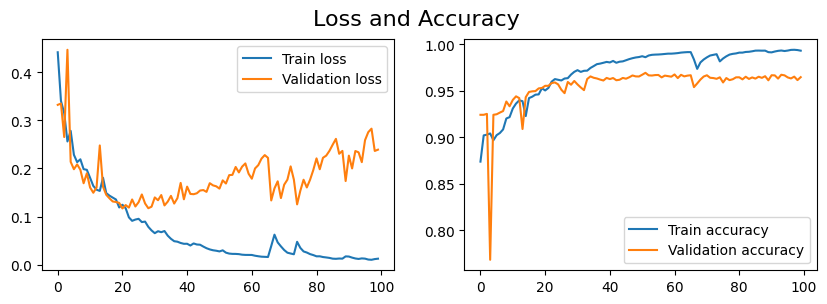

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(10,3))
ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
ax[0].legend()
ax[1].plot(history.epoch, history.history["accuracy"], label="Train accuracy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation accuracy")
ax[1].legend()
fig.suptitle('Loss and Accuracy', fontsize=16)
plt.show()

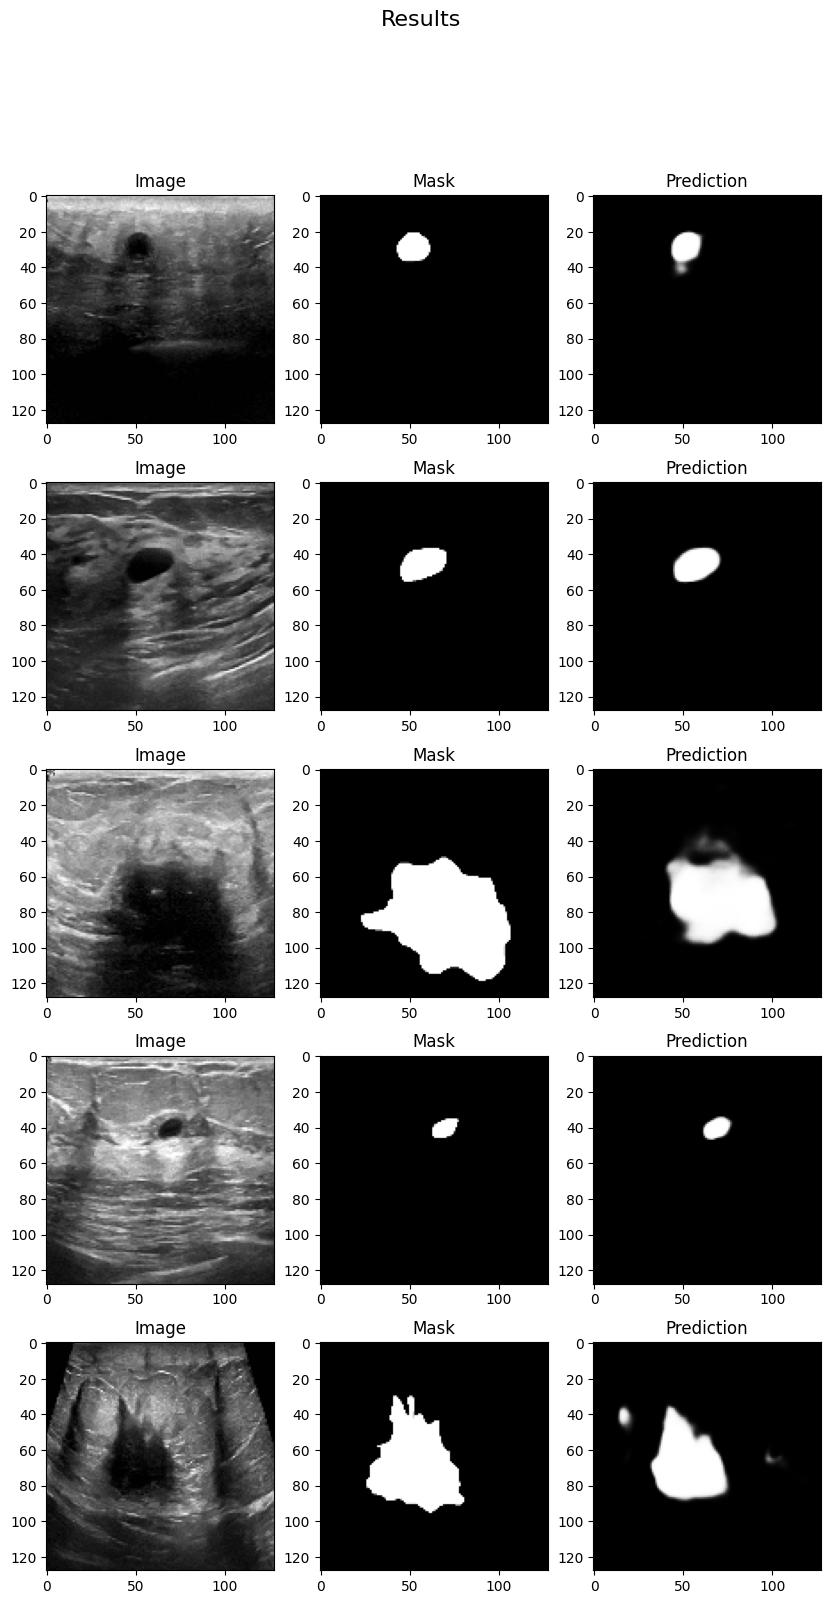

In [53]:
fig, ax = plt.subplots(5,3, figsize=(10,18))

j = np.random.randint(0, X_test.shape[0], 5)
for i in range(5):
    ax[i,0].imshow(X_test[j[i]], cmap='gray')
    ax[i,0].set_title('Image')
    ax[i,1].imshow(y_test[j[i]], cmap='gray')
    ax[i,1].set_title('Mask')
    ax[i,2].imshow(model.predict(np.expand_dims(X_test[j[i]],0),verbose=0)[0], cmap='gray')
    ax[i,2].set_title('Prediction')
fig.suptitle('Results', fontsize=16)
plt.show()

In [42]:

y_pred = model.predict(X_test, verbose=0)
y_pred_thresholded = (y_pred > 0.5).astype(np.uint8)

# Mean IoU
IOU_keras = MeanIoU(num_classes=2)
IOU_keras.update_state(y_test, y_pred_thresholded)
print("Mean IoU =", IOU_keras.result().numpy())

# Precision
prec_score = Precision()
prec_score.update_state(y_test, y_pred_thresholded)
p = prec_score.result().numpy()
print('Precision Score = %.3f' % p)

# Recall
recall_score = Recall()
recall_score.update_state(y_test, y_pred_thresholded)
r = recall_score.result().numpy()
print('Recall Score = %.3f' % r)

# F1 Score
f1_score = 2 * (p * r) / (p + r + 1e-7)   # avoid division by zero
print('F1 Score = %.3f' % f1_score)

Mean IoU = 0.7834741
Precision Score = 0.831
Recall Score = 0.684
F1 Score = 0.751


In [43]:
model.save ("Breast Cancer U_Net.h5")

In [47]:
# Prediction
y_pred = model.predict(X_test, verbose=0)
y_pred_thresholded = (y_pred > 0.5).astype(np.uint8)

# Convert ground truth to binary
y_true_binary = (y_test > 0.5).astype(np.uint8)

# Flatten
y_true_flat = y_true_binary.flatten()
y_pred_flat = y_pred_thresholded.flatten()

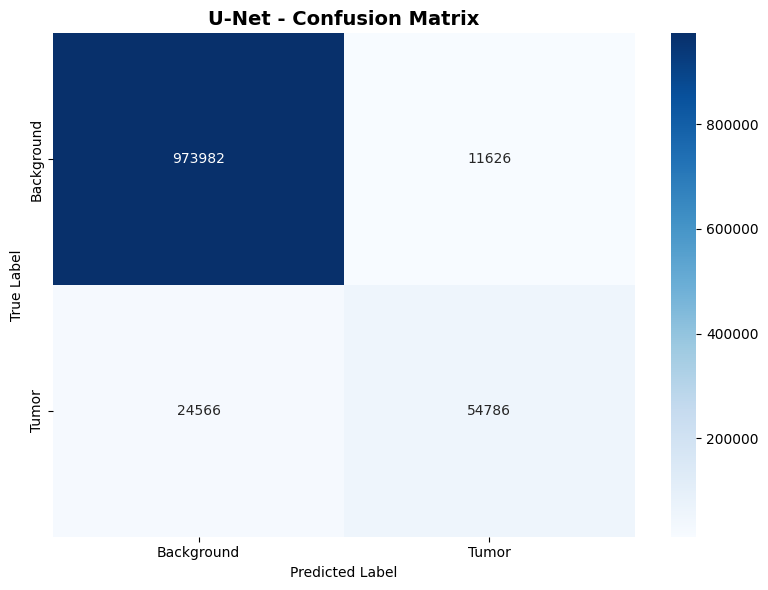

              precision    recall  f1-score   support

           0       0.98      0.99      0.98    985608
           1       0.82      0.69      0.75     79352

    accuracy                           0.97   1064960
   macro avg       0.90      0.84      0.87   1064960
weighted avg       0.96      0.97      0.96   1064960



In [50]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_flat, y_pred_flat)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Tumor'],
            yticklabels=['Background', 'Tumor'])

plt.title('U-Net - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(y_true_flat, y_pred_flat))